<a href="https://colab.research.google.com/github/vishnubyneni/MLA0202-MACHINE-LEARNING/blob/main/Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# DATA UNDERSTANDING


In [ ]:
df=pd.read_excel("/content/Ad_Sales_Data.xlsx")
print(df)

    TV_Ad_Spend  Radio_Ad_Spend  Fridge_Ad_Spend  Total_Sales
0           230              37               69         2210
1            44              39               45          920
2            17              45               69          980
3           151              41               58         1650
4           180              10               34         1420
5             8              48               12          750
6            57              32               23         1100
7           120              19               30         1350
8           200              30               60         2000
9            90              22               45         1300
10           15              10                5          400
11          300              40               80         2600
12          250              35               70         2300
13          175              20               50         1700
14           60              15               20          900
15      

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   TV_Ad_Spend      20 non-null     int64
 1   Radio_Ad_Spend   20 non-null     int64
 2   Fridge_Ad_Spend  20 non-null     int64
 3   Total_Sales      20 non-null     int64
dtypes: int64(4)
memory usage: 772.0 bytes


In [ ]:
df.isnull().sum()

,0
TV_Ad_Spend,0
Radio_Ad_Spend,0
Fridge_Ad_Spend,0
Total_Sales,0


In [ ]:
df.describe()

,TV_Ad_Spend,Radio_Ad_Spend,Fridge_Ad_Spend,Total_Sales
count,20.000000,20.000000,20.000000,20.000000
mean,123.600000,28.900000,44.750000,1446.500000
std,85.586152,12.476926,22.021222,615.161725
min,8.000000,10.000000,5.000000,400.000000
25%,55.250000,18.750000,28.750000,965.000000
50%,107.500000,31.000000,45.000000,1325.000000
75%,185.000000,39.250000,62.250000,1850.000000
max,300.000000,48.000000,80.000000,2600.000000


In [ ]:
df.head()

,TV_Ad_Spend,Radio_Ad_Spend,Fridge_Ad_Spend,Total_Sales
0,230,37,69,2210
1,44,39,45,920
2,17,45,69,980
3,151,41,58,1650
4,180,10,34,1420


In [ ]:
df["total_spend"]=df["TV_Ad_Spend"]+df["Radio_Ad_Spend"]+df["Fridge_Ad_Spend"]

In [ ]:
df

,TV_Ad_Spend,Radio_Ad_Spend,Fridge_Ad_Spend,Total_Sales,total_spend
0,230,37,69,2210,336
1,44,39,45,920,128
2,17,45,69,980,131
3,151,41,58,1650,250
4,180,10,34,1420,224
5,8,48,12,750,68
6,57,32,23,1100,112
7,120,19,30,1350,169
8,200,30,60,2000,290
9,90,22,45,1300,157


In [ ]:
df=df.drop(columns=["TV_Ad_Spend","Radio_Ad_Spend","Fridge_Ad_Spend"])

In [ ]:
df

,Total_Sales,total_spend
0,2210,336
1,920,128
2,980,131
3,1650,250
4,1420,224
5,750,68
6,1100,112
7,1350,169
8,2000,290
9,1300,157


In [ ]:
continues=["Total_Sales","total_spend"]
print(continues)

['Total_Sales', 'total_spend']


In [ ]:
df[continues].skew()

,0
Total_Sales,0.363562
total_spend,0.482211


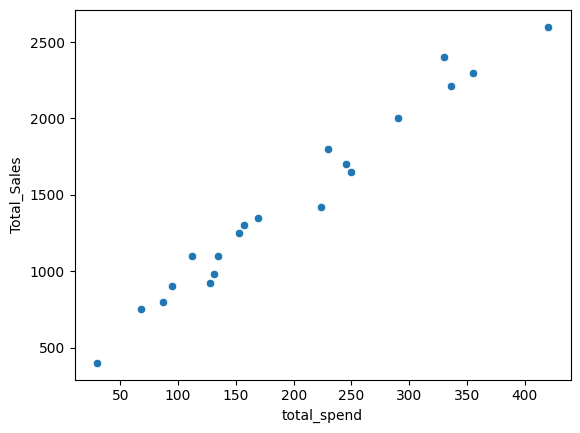

In [ ]:
sns.scatterplot(x="total_spend",y="Total_Sales",data=df)
plt.show()

In [ ]:
df[continues].corr()

,Total_Sales,total_spend
Total_Sales,1.000000,0.986295
total_spend,0.986295,1.000000


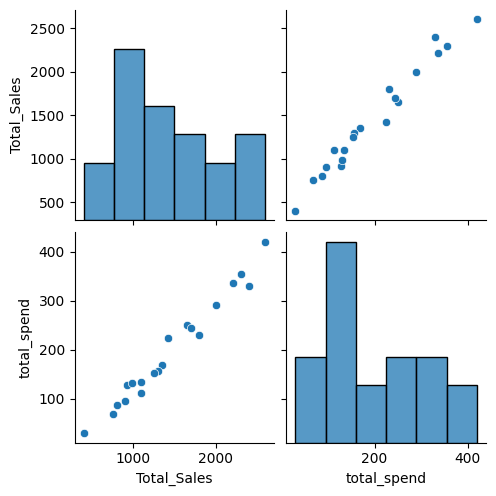

In [ ]:
sns.pairplot(df[continues])
plt.show()

# DATA PRE-PROCESSING

#DATTA WRANGLING

# MODELLING


In [ ]:
df.head()

,Total_Sales,total_spend
0,2210,336
1,920,128
2,980,131
3,1650,250
4,1420,224


In [ ]:
y=df["Total_Sales"]
x=df[["total_spend"]]

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=True)

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
model.coef_

array([5.62711769])

In [ ]:
model.intercept_

np.float64(330.06799438852295)

#EVALUATION

In [ ]:
ypres_train=model.predict(x_train)
print(ypres_train)
from sklearn.metrics import r2_score
r2=r2_score(y_train,ypres_train)
print(r2)

[1067.22041201  864.64417511 1590.54235735 2187.01683268 1281.0508843
 1050.33905894 1708.71182887 2220.77953883  819.62723357 1191.01700123
 1213.525472   1089.72888278 1961.932125   2327.69477497 2693.45742494
  712.71199743]
0.977618082846143


In [ ]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_train,ypres_train)
print(mse)
rmse=np.sqrt(mse)
print(rmse)

8064.169778789114
89.80072259614126


In [ ]:
ypred=model.predict(x_test)
print(ypred)
from sklearn.metrics import r2_score
r3=r2_score(y_test,ypred)
print(r3)

[1736.84741733 1624.3050635   960.30517587  498.88152514]
0.9439019082227302


In [ ]:
mse1=mean_squared_error(y_test,ypred)
print(mse1)
import math
rmse1=math.sqrt(mse1)
print(rmse1)

16925.846128423127
130.09937020763448


## cross_validation error

In [ ]:
from sklearn.model_selection import cross_val_score
score=cross_val_score(model,x_train,y_train,cv=5,scoring="r2")
error=score.mean()
print(error)

0.9604951750656292


MODEL_SLECTION

### OVER_FITTING

In [ ]:
# TRAIN_ERROR>TEST_ERROR
print(mse)
print(mse1)

8064.169778789114
16925.846128423127


###under_fitting

In [ ]:
# TEST_ERROR>TRAIN_ERROR
print(mse)
print(mse1)

8064.169778789114
16925.846128423127


In [ ]:
print(error)

0.9604951750656292


In [ ]:
print(mse1)

16925.846128423127


In [ ]:
model.predict([[200000]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1125753.60635031])

# SAVING THE MODEL

In [ ]:
from joblib import dump
dump(model,"sales_prediction.joblib")

['sales_prediction.joblib']

In [ ]:
from joblib import load
vishnu=load("sales_prediction.joblib")
vishnu.predict([[200000]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1125753.60635031])

In [ ]:
#deploying the model into the website

## Multiple Linear Regressioin

In [ ]:
df1=pd.read_excel("/content/Ad_Sales_Data.xlsx")
df1.head()

,TV_Ad_Spend,Radio_Ad_Spend,Fridge_Ad_Spend,Total_Sales
0,230,37,69,2210
1,44,39,45,920
2,17,45,69,980
3,151,41,58,1650
4,180,10,34,1420


In [ ]:
df1.rename(columns={"TV_Ad_Spend":"TV","Radio_Ad_Spend":"RADIO","Fridge_Ad_Spend":"FRIDGE"},inplace=True)

In [ ]:
x1=df1[["TV","RADIO","FRIDGE"]]
y1=df1["Total_Sales"]

# MODELLING


In [ ]:
from sklearn.model_selection import train_test_split
x1_train,x1_test,y1_train,y1_test=train_test_split(x1,y1,train_size=0.8,random_state=True)

In [ ]:
from sklearn.linear_model import LinearRegression
model2=LinearRegression()
model2.fit(x1,y1)
print(model2.coef_)
print(model2.intercept_)

[5.77046698 7.69564672 4.62399953]
303.9421121704779


#### The equation would be y=b1x1+b2x2+b3x3+b
# EVALUATION

In [ ]:
y1pred_train=model2.predict(x1_train)
print(y1pred_train)
from sklearn.metrics import mean_squared_error
msem2=mean_squared_error(y1_train,y1pred_train)
print(msem2)
import math
rmse2=math.sqrt(msem2)
print(rmse2)
from sklearn.metrics import r2_score
r21=r2_score(y1_train,y1pred_train)
print(r21)

[1067.40012102  858.08482234 1576.79861951 2208.84424497 1281.33542323
 1066.05286035 1698.88674436 2234.94441356  800.41321004 1175.61809736
 1200.66834702 1096.69062445 1966.34488136 2339.5864592  2712.82803703
  774.98488515]
8041.02818001575
89.67178028797996
0.977682311819585


In [ ]:
y1pred_test=model2.predict(x1_test)
print(y1pred_test)
from sklearn.metrics import mean_squared_error
msem12=mean_squared_error(y1_test,y1pred_test)
print(msem12)
import math
rmse12=math.sqrt(msem12)
print(rmse12)
from sklearn.metrics import r2_score
r22=r2_score(y1_test,y1pred_test)
print(r22)

[1758.99611435 1635.47509865  985.47141432  490.57558174]
15067.332263526134
122.74906216963996
0.9500616641706021


In [ ]:
from sklearn.model_selection import cross_val_score
score2=cross_val_score(model2,x1_train,y1_train,cv=5)
print(score2.mean())


0.9418703826156779


#MODEL SELECTION

** NO_UNDERFITTING
** NO_OVERFITTING
** CROSS VALIDATION ERROR = TRAIN EROOR
** TRAIN ERROR= TEST ERROR

* FOR TRINING THE DATA FOR DIFFERENT INPUTS OR RANDOM INPUTS WE CAN USE FOR LOOP IN THE REGUIRED RANGE
* BY TAKING CROSS_VALIDATION ACCURAY,TRAIN,TEST ACCURACY IN THE LIST FORMAT
* THESEB LIST ARE SERIES FORM THESE SERIES WILL MAKE A DATA FRAME AND PERFORM OPERATIONS  USING PANDAS

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

cv=[]
Test=[]
Train=[]
for i in range(1,100):
    # Split data
    x1_train, x1_test, y1_train, y1_test = train_test_split(x, y, train_size=0.8, random_state=i)

    # Initialize and fit model on training data of the current split
    model2 = LinearRegression()
    model2.fit(x1_train, y1_train)

    # Calculate R2 score for training data
    y1pred_train = model2.predict(x1_train)
    r21 = r2_score(y1_train, y1pred_train)
    Train.append(r21)

    # Calculate R2 score for test data
    y1pred_test = model2.predict(x1_test)
    r22 = r2_score(y1_test, y1pred_test)
    Test.append(r22) # Corrected list name from 'test' to 'Test'

    # Perform cross-validation
    score2 = cross_val_score(model2, x1_train, y1_train, cv=5)
    cv.append(score2.mean()) # Corrected variable name from 're2' to 'score2'


In [ ]:
em=pd.DataFrame({"cv":cv,"Train":Train,"Test":Test})
gm=em[abs(em["Train"]-em["cv"])<=0.05]
print(em[["Train","cv"]].max())
rs=em[em["cv"]==em["cv"].index.tolist()[0]]

Train    0.982406
cv       0.965177
dtype: float64


In [ ]:
print('Models with Train and CV R2 scores within 0.05 difference:')
print(gm.head())
print(f'Number of such models: {gm.shape[0]}')

# Explain why rs is empty
print('\nThe `rs` DataFrame is empty because the condition `em["cv"] == em["cv"].index.tolist()[0]` evaluates to `em["cv"] == 0`. Since R2 scores are generally not exactly zero (unless the model explains no variance), this condition is rarely, if ever, met.')


Models with Train and CV R2 scores within 0.05 difference:
         cv     Train      Test
0  0.960495  0.977618  0.943902
1  0.956304  0.972887  0.945370
4  0.926067  0.973003  0.964598
5  0.954938  0.979005  0.939493
7  0.945950  0.972713  0.964067
Number of such models: 49

The `rs` DataFrame is empty because the condition `em["cv"] == em["cv"].index.tolist()[0]` evaluates to `em["cv"] == 0`. Since R2 scores are generally not exactly zero (unless the model explains no variance), this condition is rarely, if ever, met.


In [ ]:
# Find the index and value of the highest 'cv' accuracy
max_cv_index = em['cv'].idxmax()
max_cv_value = em['cv'].max()

# Find the index and value of the highest 'Train' accuracy
max_train_index = em['Train'].idxmax()
max_train_value = em['Train'].max()

print(f"Highest Cross-Validation (cv) Accuracy: {max_cv_value:.4f} at index {max_cv_index}")
print(f"Highest Train Accuracy: {max_train_value:.4f} at index {max_train_index}")


Highest Cross-Validation (cv) Accuracy: 0.9652 at index 82
Highest Train Accuracy: 0.9824 at index 89


# CHECK ASSUMPTIONS

* LINEARITY OF ERRORS

<function matplotlib.pyplot.show(close=None, block=None)>

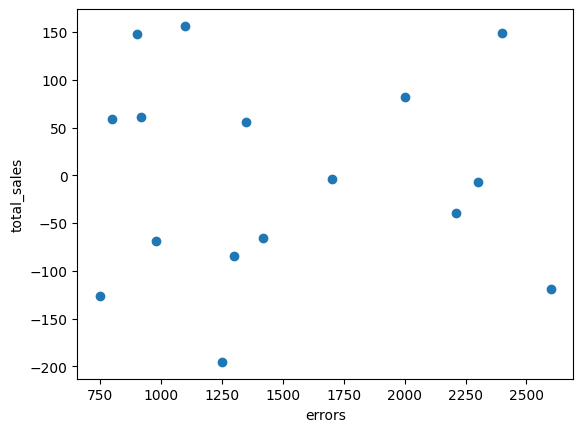

In [ ]:
train_erros=y1_train-y1pred_train
plt.scatter(y_train,train_erros)
plt.ylabel("total_sales")
plt.xlabel("errors")
plt.show


* Normality of errors

In [ ]:
train_erros.skew()

np.float64(-0.0574430075374516)

* independent errors

* Equal_variance of errors

In [ ]:
from sklearn.model_selection import train_test_split
df_tain,df_test=train_test_split(df,train_size=0.8,random_state=10)

import statsmodels.formula.api as smf
model=smf.ols("Total_Sales ~ total_spend", data=df_tain).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            Total_Sales   R-squared:                       0.969
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     437.1
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           5.89e-12
Time:                        10:09:38   Log-Likelihood:                -96.427
No. Observations:                  16   AIC:                             196.9
Df Residuals:                      14   BIC:                             198.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     316.9676     66.225      4.786      0.000     174.928     459.007
total_spend     5.6810      0.272     20.907      0.000       5.098       6.264
==============================================================================
Omnibus:                        0.726   Durbin-Watson:                   1.467
Prob(Omnibus):                  0.696   Jarque-Bera (JB):                0.542
Skew:                           0.406   Prob(JB):                        0.763
Kurtosis:                       2.610   Cond. No.                         602.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

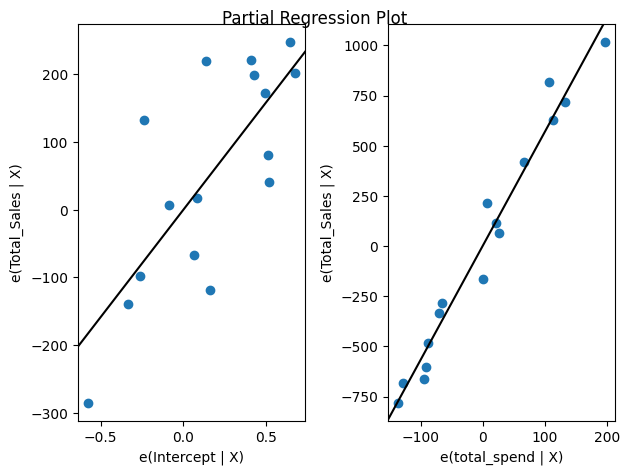

In [ ]:
import statsmodels.api as smf
smf.graphics.plot_partregress_grid(model)
plt.show()

In [ ]:
df1

,TV,RADIO,FRIDGE,Total_Sales
0,230,37,69,2210
1,44,39,45,920
2,17,45,69,980
3,151,41,58,1650
4,180,10,34,1420
5,8,48,12,750
6,57,32,23,1100
7,120,19,30,1350
8,200,30,60,2000
9,90,22,45,1300


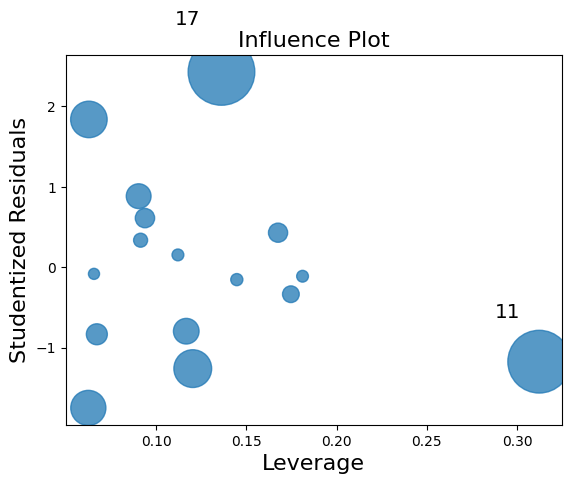

In [ ]:
import statsmodels.api as sm
sm.graphics.influence_plot(model)
plt.show()

In [ ]:
df1.head()

,TV,RADIO,FRIDGE,Total_Sales
0,230,37,69,2210
1,44,39,45,920
2,17,45,69,980
3,151,41,58,1650
4,180,10,34,1420


In [ ]:
df1=pd.read_excel("/content/Ad_Sales_Data.xlsx")
df1.rename(columns={"TV_Ad_Spend":"TV","Radio_Ad_Spend":"RADIO","Fridge_Ad_Spend":"FRIDGE"},inplace=True)
df1.drop(index=[11,17],inplace=True)

In [ ]:
x3=df1[["TV","RADIO","FRIDGE"]]
y3=df1['Total_Sales']

In [ ]:
import statsmodels.formula.api as smf
RSQ_TV=smf.ols("TV ~ RADIO+FRIDGE", data=df1).fit().rsquared
vif_tv=1/(1-RSQ_TV)
print(vif_tv)

2.2816782931269795


# SECOND ALOGORITHM

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

x1_train, x1_test, y1_train, y1_test = train_test_split(x, y, train_size=0.8, random_state=i)

model2 = LinearRegression()
model2.fit(x1_train, y1_train)

y1pred_train = model2.predict(x1_train)
r21 = r2_score(y1_train, y1pred_train)
Train.append(r21)

y1pred_test = model2.predict(x1_test)
r22 = r2_score(y1_test, y1pred_test)
Test.append(r22)

score2 = cross_val_score(model2, x1_train, y1_train, cv=5)
cv.append(score2.mean())

# Non-Linear Regression

In [ ]:
df1

,TV,RADIO,FRIDGE,Total_Sales
0,230,37,69,2210
1,44,39,45,920
2,17,45,69,980
3,151,41,58,1650
4,180,10,34,1420
5,8,48,12,750
6,57,32,23,1100
7,120,19,30,1350
8,200,30,60,2000
9,90,22,45,1300


In [ ]:
x4_train=df1[["TV","RADIO","FRIDGE"]]
y4_train=df1["Total_Sales"]

In [ ]:
from sklearn.model_selection import train_test_split
x3_train, x3_test, y3_train, y3_test = train_test_split(x, y, train_size=0.8, random_state=9)

In [ ]:
x4_train

,TV,RADIO,FRIDGE
0,230,37,69
1,44,39,45
2,17,45,69
3,151,41,58
4,180,10,34
5,8,48,12
6,57,32,23
7,120,19,30
8,200,30,60
9,90,22,45


In [ ]:
y4_train

,Total_Sales
0,2210
1,920
2,980
3,1650
4,1420
5,750
6,1100
7,1350
8,2000
9,1300


In [ ]:
from sklearn.model_selection import train_test_split
# Split the data from df1 (x3, y3) for polynomial regression to maintain consistency
x_poly_train_split, x_poly_test_split, y_poly_train_split, y_poly_test_split = train_test_split(x3, y3, train_size=0.8, random_state=9)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
polynomial_converter = PolynomialFeatures(degree=2,include_bias=False)
X_poly_train = polynomial_converter.fit_transform(x_poly_train_split)
x_train_poly=pd.DataFrame(X_poly_train, columns=polynomial_converter.get_feature_names_out(x_poly_train_split.columns))

In [ ]:
from sklearn.linear_model import LinearRegression
model4=LinearRegression()
model4.fit(x_train_poly,y_poly_train_split)

LinearRegression()

In [ ]:
model4.coef_

array([ 6.82065195e+00,  1.09575923e+01,  8.85914321e+00,  1.29289641e-03,
        1.98733615e-01, -1.42060787e-01,  1.01159032e-01, -7.65272621e-01,
        3.76844375e-01])

In [ ]:
model4.intercept_

np.float64(152.7509372593447)

In [ ]:
from sklearn.model_selection import cross_val_score

# Calculate cross-validation scores for the polynomial regression model
score_poly_cv = cross_val_score(model4, x_train_poly, y_poly_train_split, cv=5)

# Print the individual and mean cross-validation R2 scores
print(f"Polynomial Regression Cross-Validation R2 Scores per fold: {score_poly_cv}")
print(f"Polynomial Regression Mean Cross-Validation R2 Score: {score_poly_cv.mean():.4f}")

Polynomial Regression Cross-Validation R2 Scores per fold: [ 0.58372115  0.90219357 -3.30474206  0.95924111  0.9665683 ]
Polynomial Regression Mean Cross-Validation R2 Score: 0.0214


In [ ]:
from  sklearn.metrics import mean_squared_error
y4_pred_train=model4.predict(x_train_poly)
mse4=mean_squared_error(y_poly_train_split,y4_pred_train)
print(mse4)

263.0718763239756


In [ ]:
import math
rmse4=math.sqrt(mse4)

In [ ]:
from sklearn.metrics import r2_score
r4_score=r2_score(y_poly_train_split,y4_pred_train)
r4_score

0.9991411471823656

In [ ]:
# Transform the test features using the same polynomial converter
X_poly_test = polynomial_converter.transform(x_poly_test_split)
x_test_poly = pd.DataFrame(X_poly_test, columns=polynomial_converter.get_feature_names_out(x_poly_test_split.columns))

# Make predictions on the test set
y_poly_pred_test = model4.predict(x_test_poly)

# Calculate MSE for the test set
mse_poly_test = mean_squared_error(y_poly_test_split, y_poly_pred_test)
print(f"Polynomial Regression Test MSE: {mse_poly_test:.2f}")

# Calculate RMSE for the test set
rmse_poly_test = np.sqrt(mse_poly_test)
print(f"Polynomial Regression Test RMSE: {rmse_poly_test:.2f}")

# Calculate R2 score for the test set
r2_poly_test = r2_score(y_poly_test_split, y_poly_pred_test)
print(f"Polynomial Regression Test R2: {r2_poly_test:.2f}")

Polynomial Regression Test MSE: 11780.98
Polynomial Regression Test RMSE: 108.54
Polynomial Regression Test R2: 0.83


Model Deployement Using Flask

REGULARIZATION


* Lasso Regression

## Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y) using the cleaned df1
X_ridge = df1[["TV","RADIO","FRIDGE"]]
y_ridge = df1["Total_Sales"]

# Split the data into training and testing sets
X_ridge_train, X_ridge_test, y_ridge_train, y_ridge_test = train_test_split(X_ridge, y_ridge, train_size=0.8, random_state=42)

# Scale the features
scaler_ridge = StandardScaler()
X_ridge_train_scaled = scaler_ridge.fit_transform(X_ridge_train)
X_ridge_test_scaled = scaler_ridge.transform(X_ridge_test)

# Initialize and fit the Ridge model
ridge_model = Ridge(alpha=1.0) # You can tune the alpha parameter
ridge_model.fit(X_ridge_train_scaled, y_ridge_train)

# Make predictions on training and test sets
y_ridge_pred_train = ridge_model.predict(X_ridge_train_scaled)
y_ridge_pred_test = ridge_model.predict(X_ridge_test_scaled)

# Evaluate the Ridge model on the training set
mse_ridge_train = mean_squared_error(y_ridge_train, y_ridge_pred_train)
rmse_ridge_train = np.sqrt(mse_ridge_train)
r2_ridge_train = r2_score(y_ridge_train, y_ridge_pred_train)

# Evaluate the Ridge model on the test set
mse_ridge_test = mean_squared_error(y_ridge_test, y_ridge_pred_test)
rmse_ridge_test = np.sqrt(mse_ridge_test)
r2_ridge_test = r2_score(y_ridge_test, y_ridge_pred_test)

# Perform cross-validation
cv_scores_ridge = cross_val_score(ridge_model, X_ridge_train_scaled, y_ridge_train, cv=5, scoring='r2')

print(f"Ridge Model Coefficients: {ridge_model.coef_}")
print(f"Ridge Model Intercept: {ridge_model.intercept_}")
print("\n--- Training Set Evaluation ---")
print(f"R2 Score (Train): {r2_ridge_train:.4f}")
print(f"Mean Squared Error (Train): {mse_ridge_train:.2f}")
print(f"Root Mean Squared Error (Train): {rmse_ridge_train:.2f}")
print("\n--- Test Set Evaluation ---")
print(f"R2 Score (Test): {r2_ridge_test:.4f}")
print(f"Mean Squared Error (Test): {mse_ridge_test:.2f}")
print(f"Root Mean Squared Error (Test): {rmse_ridge_test:.2f}")
print("\n--- Cross-Validation Evaluation ---")
print(f"Cross-Validation R2 Scores: {cv_scores_ridge}")
print(f"Mean Cross-Validation R2 Score: {cv_scores_ridge.mean():.4f}")


Ridge Model Coefficients: [337.16363368  84.24037226  92.72257004]
Ridge Model Intercept: 1289.2857142857142

--- Training Set Evaluation ---
R2 Score (Train): 0.9583
Mean Squared Error (Train): 8790.66
Root Mean Squared Error (Train): 93.76

--- Test Set Evaluation ---
R2 Score (Test): 0.9709
Mean Squared Error (Test): 11983.55
Root Mean Squared Error (Test): 109.47

--- Cross-Validation Evaluation ---
Cross-Validation R2 Scores: [0.9191142  0.77923941 0.82877852 0.95064729 0.        ]
Mean Cross-Validation R2 Score: 0.6956


## Elastic Net Regression

In [ ]:
from sklearn.linear_model import ElasticNet

# Define features (X) and target (y) using the cleaned df1
X_elastic = df1[["TV","RADIO","FRIDGE"]]
y_elastic = df1["Total_Sales"]

# Split the data into training and testing sets
X_elastic_train, X_elastic_test, y_elastic_train, y_elastic_test = train_test_split(X_elastic, y_elastic, train_size=0.8, random_state=42)

# Scale the features
scaler_elastic = StandardScaler()
X_elastic_train_scaled = scaler_elastic.fit_transform(X_elastic_train)
X_elastic_test_scaled = scaler_elastic.transform(X_elastic_test)

# Initialize and fit the ElasticNet model
elastic_model = ElasticNet(alpha=1.0, l1_ratio=0.5) # You can tune alpha and l1_ratio
elastic_model.fit(X_elastic_train_scaled, y_elastic_train)

# Make predictions on training and test sets
y_elastic_pred_train = elastic_model.predict(X_elastic_train_scaled)
y_elastic_pred_test = elastic_model.predict(X_elastic_test_scaled)

# Evaluate the ElasticNet model on the training set
mse_elastic_train = mean_squared_error(y_elastic_train, y_elastic_pred_train)
rmse_elastic_train = np.sqrt(mse_elastic_train)
r2_elastic_train = r2_score(y_elastic_train, y_elastic_pred_train)

# Evaluate the ElasticNet model on the test set
mse_elastic_test = mean_squared_error(y_elastic_test, y_elastic_pred_test)
rmse_elastic_test = np.sqrt(mse_elastic_test)
r2_elastic_test = r2_score(y_elastic_test, y_elastic_pred_test)

# Perform cross-validation
cv_scores_elastic = cross_val_score(elastic_model, X_elastic_train_scaled, y_elastic_train, cv=5, scoring='r2')

print(f"ElasticNet Model Coefficients: {elastic_model.coef_}")
print(f"ElasticNet Model Intercept: {elastic_model.intercept_}")
print("\n--- Training Set Evaluation ---")
print(f"R2 Score (Train): {r2_elastic_train:.4f}")
print(f"Mean Squared Error (Train): {mse_elastic_train:.2f}")
print(f"Root Mean Squared Error (Train): {rmse_elastic_train:.2f}")
print("\n--- Test Set Evaluation ---")
print(f"R2 Score (Test): {r2_elastic_test:.4f}")
print(f"Mean Squared Error (Test): {mse_elastic_test:.2f}")
print(f"Root Mean Squared Error (Test): {rmse_elastic_test:.2f}")
print("\n--- Cross-Validation Evaluation ---")
print(f"Cross-Validation R2 Scores: {cv_scores_elastic}")
print(f"Mean Cross-Validation R2 Score: {cv_scores_elastic.mean():.4f}")


ElasticNet Model Coefficients: [234.61629039  58.08661108 116.22756509]
ElasticNet Model Intercept: 1289.2857142857142

--- Training Set Evaluation ---
R2 Score (Train): 0.8922
Mean Squared Error (Train): 22737.26
Root Mean Squared Error (Train): 150.79

--- Test Set Evaluation ---
R2 Score (Test): 0.8913
Mean Squared Error (Test): 44823.84
Root Mean Squared Error (Test): 211.72

--- Cross-Validation Evaluation ---
Cross-Validation R2 Scores: [0.98787933 0.5810945  0.87687199 0.85768849 0.        ]
Mean Cross-Validation R2 Score: 0.6607


## Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y) using the cleaned df1
X_lasso = df1[["TV","RADIO","FRIDGE"]]
y_lasso = df1["Total_Sales"]

# Split the data into training and testing sets
X_lasso_train, X_lasso_test, y_lasso_train, y_lasso_test = train_test_split(X_lasso, y_lasso, train_size=0.8, random_state=42)

# Scale the features
scaler_lasso = StandardScaler()
X_lasso_train_scaled = scaler_lasso.fit_transform(X_lasso_train)
X_lasso_test_scaled = scaler_lasso.transform(X_lasso_test)

# Initialize and fit the Lasso model
lasso_model = Lasso(alpha=0.1) # You can tune the alpha parameter
lasso_model.fit(X_lasso_train_scaled, y_lasso_train)

# Make predictions on training and test sets
y_lasso_pred_train = lasso_model.predict(X_lasso_train_scaled)
y_lasso_pred_test = lasso_model.predict(X_lasso_test_scaled)

# Evaluate the Lasso model on the training set
mse_lasso_train = mean_squared_error(y_lasso_train, y_lasso_pred_train)
rmse_lasso_train = np.sqrt(mse_lasso_train)
r2_lasso_train = r2_score(y_lasso_train, y_lasso_pred_train)

# Evaluate the Lasso model on the test set
mse_lasso_test = mean_squared_error(y_lasso_test, y_lasso_pred_test)
rmse_lasso_test = np.sqrt(mse_lasso_test)
r2_lasso_test = r2_score(y_lasso_test, y_lasso_pred_test)

# Perform cross-validation
cv_scores_lasso = cross_val_score(lasso_model, X_lasso_train_scaled, y_lasso_train, cv=5, scoring='r2')

print(f"Lasso Model Coefficients: {lasso_model.coef_}")
print(f"Lasso Model Intercept: {lasso_model.intercept_}")
print("\n--- Training Set Evaluation ---")
print(f"R2 Score (Train): {r2_lasso_train:.4f}")
print(f"Mean Squared Error (Train): {mse_lasso_train:.2f}")
print(f"Root Mean Squared Error (Train): {rmse_lasso_train:.2f}")
print("\n--- Test Set Evaluation ---")
print(f"R2 Score (Test): {r2_lasso_test:.4f}")
print(f"Mean Squared Error (Test): {mse_lasso_test:.2f}")
print(f"Root Mean Squared Error (Test): {rmse_lasso_test:.2f}")
print("\n--- Cross-Validation Evaluation ---")
print(f"Cross-Validation R2 Scores: {cv_scores_lasso}")
print(f"Mean Cross-Validation R2 Score: {cv_scores_lasso.mean():.4f}")

Lasso Model Coefficients: [376.21998463 111.26371725  57.46948504]
Lasso Model Intercept: 1289.2857142857142

--- Training Set Evaluation ---
R2 Score (Train): 0.9625
Mean Squared Error (Train): 7919.19
Root Mean Squared Error (Train): 88.99

--- Test Set Evaluation ---
R2 Score (Test): 0.9700
Mean Squared Error (Test): 12390.33
Root Mean Squared Error (Test): 111.31

--- Cross-Validation Evaluation ---
Cross-Validation R2 Scores: [0.82098237 0.85734833 0.77421031 0.96531154 0.        ]
Mean Cross-Validation R2 Score: 0.6836
